# DeepSeek 100K BPE token 结构与权重统计

1. 用官方 tokenizer 统计每个 token 的最终输出次数 `final_count`。
2. 根据 merge 表建立构造树，并按 merge rank 从父节点向子节点传播频次。
3. 子节点收到的传播量是 `internal_count`；两者之和是 `instantiated_count`。
4. `final_ratio = final_count / instantiated_count`。
5. 将合法 token 按输出频率、special、added 和脚手架候选分组。
6. 分别分析 untied input embedding 与 `lm_head` 的行范数、坐标分布和几何结构。
7. 可选加载完整模型，检查各组 token 在真实 logits 中的概率质量。

当前只分析 [`deepseek-ai/deepseek-llm-7b-base`](https://huggingface.co/deepseek-ai/deepseek-llm-7b-base)。语料通过 Hugging Face `datasets` 流式读取，每个来源截取相同的 UTF-8 字节数，避免某一类语料仅因体量更大而主导统计。

默认语料分四组：中英文 Wikipedia 提供同领域语言基线；FineWeb-Edu 补充真实英文网页；The Stack Smol XS 的 Python、JavaScript、TypeScript 观察代码；OpenWebMath 观察数学与 LaTeX。它们用于分析词表结构，不应被理解为完整代表模型的真实训练分布。


In [19]:
from pathlib import Path

from huggingface_hub import hf_hub_download

MODEL_ID = "deepseek-ai/deepseek-llm-7b-base"
TOKENIZER_PATH = Path(hf_hub_download(MODEL_ID, "tokenizer.json"))
MODEL_CONFIG_PATH = Path(hf_hub_download(MODEL_ID, "config.json"))

# 中英文百科用于可比的语言基线；FineWeb-Edu补充英文网页；
# The Stack Smol XS补充代码；OpenWebMath补充数学和LaTeX。
# 直接指向Parquet文件，避免依赖已被datasets 5移除的旧式数据集脚本。
CORPORA = [
    {"name": "zh_wikipedia", "data_files": "hf://datasets/wikimedia/wikipedia@refs/convert/parquet/20231101.zh/train/*.parquet", "field": "text"},
    {"name": "en_wikipedia", "data_files": "hf://datasets/wikimedia/wikipedia@refs/convert/parquet/20231101.en/train/*.parquet", "field": "text"},
    {"name": "en_fineweb_edu", "data_files": "hf://datasets/HuggingFaceFW/fineweb-edu/sample/10BT/*.parquet", "field": "text"},
    {"name": "code_python", "data_files": "hf://datasets/bigcode/the-stack-smol-xs@refs/convert/parquet/python/train/*.parquet", "field": "content"},
    {"name": "code_javascript", "data_files": "hf://datasets/bigcode/the-stack-smol-xs@refs/convert/parquet/javascript/train/*.parquet", "field": "content"},
    {"name": "code_typescript", "data_files": "hf://datasets/bigcode/the-stack-smol-xs@refs/convert/parquet/typescript/train/*.parquet", "field": "content"},
    {"name": "math_web", "data_files": "hf://datasets/open-web-math/open-web-math/data/*.parquet", "field": "text"},
]

TARGET_BYTES_PER_CORPUS = 10_000_000
SHUFFLE_BUFFER = 10_000
OUTPUT_PATH = Path("token_structure.csv")

In [20]:
import json
from collections import defaultdict

import pandas as pd
from datasets import load_dataset
from tokenizers import Tokenizer
from tokenizers.pre_tokenizers import ByteLevel

config = json.loads(TOKENIZER_PATH.read_text(encoding="utf-8"))
model = config["model"]
model_config = json.loads(MODEL_CONFIG_PATH.read_text(encoding="utf-8"))

# 当前研究对象已经固定为DeepSeek 7B Base，所以这里只展示类型，
# 不为其他tokenizer类型增加兼容分支。后续代码直接使用BPE的merges字段。
print(f"tokenizer model type: {model['type']}")

tokenizer = Tokenizer.from_file(str(TOKENIZER_PATH))
# model['vocab']只有10万个BPE模型token；with_added_tokens=True
# 还会包含训练完成后追加的token，当前总数为100015。
vocab = tokenizer.get_vocab(with_added_tokens=True)
id_to_token = {token_id: token for token, token_id in vocab.items()}
# AddedToken由tokenizer的added-token层（在BPE model之外）直接识别。
# 因此它们可以成为最终输出，却不会成为merge的输入或输出。
added = {item["id"] for item in config.get("added_tokens", [])}
special = {
    item["id"] for item in config.get("added_tokens", []) if item.get("special")
}

children = {}
merge_rank = {}
parents = defaultdict(set)

# 每条merge定义一个二叉构造关系：left + right -> merged。
# 图必须使用tokenizer内部字符串（例如Ġ），不能先decode成人类文本。
for rank, item in enumerate(model["merges"]):
    left, right = item if isinstance(item, list) else item.split(" ", 1)
    merged = left + right
    try:
        merged_id, left_id, right_id = vocab[merged], vocab[left], vocab[right]
    except KeyError as error:
        raise ValueError(f"无法解析 merge #{rank}: {left!r} + {right!r}") from error

    children[merged_id] = (left_id, right_id)
    merge_rank[merged_id] = rank
    parents[left_id].add(merged_id)
    parents[right_id].add(merged_id)

byte_alphabet = set(ByteLevel.alphabet())
model_tokens = set(model["vocab"])
added_non_special = {
    item["content"] for item in config.get("added_tokens", []) if not item.get("special")
}
missing_byte_symbols = byte_alphabet - model_tokens

# ByteLevel用256个可见Unicode字符一一表示256种byte。合法UTF-8不会含有
# C0、C1、F5-FF这13种byte，因此由合法Unicode语料训练出的model vocab
# 只保留了其余243个基础符号。tokenizer又把缺少的13个同名字符放进
# added_tokens，看起来是在BPE训练后补齐形式上的256符号字母表。
# 注意：这是从文件结构推断的用途，官方没有单独解释；它们绕过BPE，
# 既不参与merge，也不应和243个真正的BPE基础byte token混在一起分析。
invalid_utf8_bytes = {0xC0, 0xC1, *range(0xF5, 0x100)}
invalid_utf8_byte_symbols = {chr(value) for value in invalid_utf8_bytes}
merge_node_ids = set(children) | set(parents)

pd.Series({
    "BPE model vocab": len(model["vocab"]),
    "merge tokens": len(children),
    "base symbols in model vocab": len(model["vocab"]) - len(children),
    "added non-special tokens": len(added - special),
    "special tokens": len(special),
    "total tokenizer IDs": len(vocab),
    "model embedding rows": model_config["vocab_size"],
    "embedding-only rows": model_config["vocab_size"] - len(vocab),
    "missing symbols equal invalid UTF-8 bytes": missing_byte_symbols == invalid_utf8_byte_symbols,
    "missing symbols equal added non-special tokens": missing_byte_symbols == added_non_special,
    "added non-special tokens participate in merges": bool((added - special) & merge_node_ids),
}, name="value").to_frame()

tokenizer model type: BPE


,value
BPE model vocab,100000
merge tokens,99757
base symbols in model vocab,243
added non-special tokens,13
special tokens,2
total tokenizer IDs,100015
model embedding rows,102400
embedding-only rows,2385
missing symbols equal invalid UTF-8 bytes,True
missing symbols equal added non-special tokens,True


In [3]:
final_counts = defaultdict(int)
final_counts_by_corpus = {}
corpus_stats = []

for spec in CORPORA:
    # streaming=True按需下载远程Parquet分片，只读到目标字节数，不下载全量。
    stream = load_dataset(
        "parquet", data_files=spec["data_files"], split="train", streaming=True
    ).shuffle(seed=42, buffer_size=SHUFFLE_BUFFER)

    counts = defaultdict(int)
    bytes_seen = documents = token_count = 0
    for row in stream:
        text = row[spec["field"]]
        if not text:
            continue

        # 最后一篇文档按UTF-8 byte截断，使各语料的规模尽量一致。
        raw = text.encode("utf-8")
        remaining = TARGET_BYTES_PER_CORPUS - bytes_seen
        is_last = len(raw) >= remaining
        if is_last:
            text = raw[:remaining].decode("utf-8", errors="ignore")

        # 每条数据独立编码，避免把两篇无关文档的结尾和开头合并。
        token_ids = tokenizer.encode(text, add_special_tokens=False).ids
        for token_id in token_ids:
            counts[token_id] += 1
            final_counts[token_id] += 1

        bytes_seen += len(text.encode("utf-8"))
        documents += 1
        token_count += len(token_ids)
        if is_last:
            break

    if bytes_seen < TARGET_BYTES_PER_CORPUS:
        print(f"warning: {spec['name']}只有{bytes_seen:,} bytes，未达到目标")

    final_counts_by_corpus[spec["name"]] = counts
    corpus_stats.append({
        "corpus": spec["name"],
        "documents": documents,
        "utf8_bytes": bytes_seen,
        "final_tokens": token_count,
    })

corpus_stats_df = pd.DataFrame(corpus_stats)
corpus_stats_df

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/114 [00:00<?, ?it/s]

,corpus,documents,utf8_bytes,final_tokens
0,zh_wikipedia,5500,10000000,3663729
1,en_wikipedia,4411,10000000,2554207
2,en_fineweb_edu,2247,10000000,2189865
3,code_python,100,913302,346953
4,code_javascript,100,1772457,669205
5,code_typescript,100,902522,259007
6,math_web,1222,10000000,2728203


In [4]:
# instantiated先包含所有最终输出。按merge rank倒序处理父节点：
# 父token每出现一次，它的两个子token就各作为内部节点出现一次。
# 必须倒序，否则子节点在收到父节点贡献前就已经向下传播，会漏计。
instantiated = defaultdict(int, final_counts)
for token_id in sorted(merge_rank, key=merge_rank.get, reverse=True):
    count = instantiated[token_id]
    if count:
        left_id, right_id = children[token_id]
        instantiated[left_id] += count
        instantiated[right_id] += count

# 每个逻辑token实例最终只能被更长token吸收，或留在最终输出中。
# 因此 instantiated = internal + final。
internal_counts = {
    token_id: count - final_counts[token_id]
    for token_id, count in instantiated.items()
}

# 深度反过来按rank正序计算，保证计算父节点前两个子节点已有深度。
depths = defaultdict(int)
for token_id in sorted(merge_rank, key=merge_rank.get):
    left_id, right_id = children[token_id]
    depths[token_id] = 1 + max(depths[left_id], depths[right_id])

In [5]:
def token_kind(token_id):
    # special是added的子集，所以必须先判断special。
    if token_id in special:
        return "special"
    if token_id in added:
        # added token可以最终输出，但没有merge rank、children或parents。
        return "added"
    if token_id in children:
        return "merged"
    return "base"

rows = []
for token_id, token in sorted(id_to_token.items()):
    left_id, right_id = children.get(token_id, (None, None))
    final = final_counts[token_id]
    total = instantiated[token_id]
    row = {
        "id": token_id,
        "token": token,
        "decoded": tokenizer.decode([token_id], skip_special_tokens=False),
        "kind": token_kind(token_id),
        "merge_rank": merge_rank.get(token_id),
        "left_id": left_id,
        "left_token": None if left_id is None else id_to_token[left_id],
        "right_id": right_id,
        "right_token": None if right_id is None else id_to_token[right_id],
        "parent_count": len(parents[token_id]),
        "depth": depths[token_id],
        "final_count": final,
        "internal_count": internal_counts.get(token_id, 0),
        "instantiated_count": total,
        "final_ratio": None if total == 0 else final / total,
    }
    # 保留各语料的最终频次，后续可以直接比较中文、英文和代码。
    for corpus_name, counts in final_counts_by_corpus.items():
        row[f"final_count__{corpus_name}"] = counts[token_id]
    rows.append(row)

df = pd.DataFrame(rows)
df.to_csv(OUTPUT_PATH, index=False)

pd.Series({
    "vocab": len(vocab),
    "merges": len(children),
    "corpus_utf8_bytes": int(corpus_stats_df["utf8_bytes"].sum()),
    "final_tokens": sum(final_counts.values()),
    "output": str(OUTPUT_PATH),
}, name="value").to_frame()

,value
vocab,100015
merges,99757
corpus_utf8_bytes,43588281
final_tokens,12411169
output,token_structure.csv


In [6]:
# 只考察语料中实际出现过的merge token。基础byte即使final_ratio很低，
# 也承担兜底职责；special/added则不属于BPE merge容量分配问题。
# 低final_ratio且高instantiated_count表示它经常参与构造、很少最终输出，
# 这里只称为scaffold候选，不能直接称为废token。
candidates = (
    df[(df["kind"] == "merged") & (df["instantiated_count"] > 0)]
    .sort_values(["final_ratio", "instantiated_count"], ascending=[True, False])
)
candidates.head(50)

,id,token,decoded,kind,merge_rank,left_id,left_token,right_id,right_token,parent_count,...,internal_count,instantiated_count,final_ratio,final_count__zh_wikipedia,final_count__en_wikipedia,final_count__en_fineweb_edu,final_count__code_python,final_count__code_javascript,final_count__code_typescript,final_count__math_web
2731,2731,¥¿,��,merged,2488.0,98.0,¥,123.0,¿,2,...,7737,7737,0.0,0,0,0,0,0,0,0
872,872,¦ģ,��,merged,629.0,99.0,¦,210.0,ģ,2,...,4477,4477,0.0,0,0,0,0,0,0,0
999,999,ublic,ublic,merged,756.0,458.0,ub,811.0,lic,7,...,3661,3661,0.0,0,0,0,0,0,0,0
1478,1478,Ġexper,exper,merged,1235.0,411.0,Ġex,524.0,per,7,...,2479,2479,0.0,0,0,0,0,0,0,0
2529,2529,ponse,ponse,merged,2286.0,1480.0,pon,346.0,se,4,...,1901,1901,0.0,0,0,0,0,0,0,0
2192,2192,Ġcomple,comple,merged,1949.0,591.0,Ġcomp,275.0,le,6,...,1875,1875,0.0,0,0,0,0,0,0,0
2905,2905,ources,ources,merged,2662.0,416.0,our,1524.0,ces,8,...,1612,1612,0.0,0,0,0,0,0,0,0
2173,2173,Ġiss,iss,merged,1930.0,317.0,Ġis,82.0,s,6,...,1529,1529,0.0,0,0,0,0,0,0,0
2767,2767,urther,urther,merged,2524.0,332.0,ur,607.0,ther,4,...,1499,1499,0.0,0,0,0,0,0,0,0
3724,3724,Ġestab,estab,merged,3481.0,859.0,Ġest,356.0,ab,5,...,1461,1461,0.0,0,0,0,0,0,0,0


## 2. Embedding / LM head 权重诊断

这一节回答的是：**不同使用状态的 token，其权重有没有可识别的统计差异？** 它不能仅凭最终 checkpoint 证明某一行“从未被训练”，因为我们没有保存初始化权重和训练日志。

必须分开分析两张未绑定的表：

- `model.embed_tokens.weight`：token 作为输入时查询的 embedding；不可达的 padding 行通常收不到数据梯度。
- `lm_head.weight`：token 作为输出类别时使用的权重；即使目标中从未出现，未被 mask 的行仍可能通过 softmax 分母收到负梯度。

分组中的 `final_count` 只来自上面抽取的评估语料，是预训练频率的 **proxy**，不是 DeepSeek 的真实训练计数。`scaffold_candidate` 也只是“低 final ratio、但经常作为内部节点”的启发式候选，不能直接叫废 token。

DeepSeek 7B 的官方权重是两个 PyTorch 分片：input embedding 在约 9.97 GB 的第一个分片，`lm_head` 在约 3.85 GB 的第二个分片。下面用 `mmap=True` 分片处理，降低 RAM 峰值，但不会减少磁盘下载量。第一次试跑可以只设 `MATRICES_TO_ANALYZE = ("output_head",)`。


In [7]:
import gc
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

WEIGHT_KEYS = {
    "input_embedding": "model.embed_tokens.weight",
    "output_head": "lm_head.weight",
}
MATRICES_TO_ANALYZE = tuple(WEIGHT_KEYS)  # 只想先下载3.85 GB时改成("output_head",)

RANDOM_SEED = 42
SAMPLE_ROWS_PER_GROUP = 256
SCAFFOLD_TOP_N = 1_000
FREQUENCY_MASS_CUTS = (0.80, 0.95)
WEIGHT_OUTPUT_DIR = Path("embedding_analysis")
WEIGHT_OUTPUT_DIR.mkdir(exist_ok=True)

weight_index_path = Path(hf_hub_download(MODEL_ID, "pytorch_model.bin.index.json"))
weight_index = json.loads(weight_index_path.read_text(encoding="utf-8"))
weight_map = weight_index["weight_map"]

MODEL_VOCAB_SIZE = int(model_config["vocab_size"])
HIDDEN_SIZE = int(model_config["hidden_size"])
INIT_STD = float(model_config["initializer_range"])
EXPECTED_RANDOM_NORM = INIT_STD * math.sqrt(HIDDEN_SIZE)

pd.Series({
    "model_vocab_size": MODEL_VOCAB_SIZE,
    "tokenizer_reachable_ids": len(vocab),
    "embedding_only_rows": MODEL_VOCAB_SIZE - len(vocab),
    "hidden_size": HIDDEN_SIZE,
    "initializer_range": INIT_STD,
    "iid_normal_expected_row_norm": EXPECTED_RANDOM_NORM,
    "tie_word_embeddings": model_config["tie_word_embeddings"],
    "checkpoint_size_GB": weight_index["metadata"]["total_size"] / 1e9,
}, name="value").to_frame()


pytorch_model.bin.index.json:   0%|          | 0.00/22.5k [00:00<?, ?B/s]

,value
model_vocab_size,102400
tokenizer_reachable_ids,100015
embedding_only_rows,2385
hidden_size,4096
initializer_range,0.02
iid_normal_expected_row_norm,1.28
tie_word_embeddings,False
checkpoint_size_GB,13.820731


### 2.1 形成互斥的 token 分组

频率组不是按“类型数量三等分”，而是按 token 流的累计概率质量划分：覆盖前 80% 的类型为高频，80%–95% 为中频，其余已出现类型为低频。这样更接近“模型实际看见了多少次”。优先级为：embedding-only → special → added → scaffold candidate → unseen → 高频/中频/低频。


In [8]:
GROUP_ORDER = [
    "padded_unreachable",
    "special",
    "added_non_special",
    "scaffold_candidate",
    "unseen_valid",
    "low_frequency",
    "mid_frequency",
    "high_frequency",
]

# 复用上一节的脚手架排序；固定取前N名只是为了形成可比较样本。
scaffold_ids = set(candidates.head(SCAFFOLD_TOP_N)["id"].astype(int))
valid_ids = set(vocab.values())

token_table = pd.DataFrame({"id": np.arange(MODEL_VOCAB_SIZE)})
token_table = token_table.merge(
    df[[
        "id", "token", "decoded", "kind", "depth", "merge_rank",
        "final_count", "internal_count", "instantiated_count", "final_ratio",
    ]],
    on="id",
    how="left",
)
for column in ["final_count", "internal_count", "instantiated_count"]:
    token_table[column] = token_table[column].fillna(0).astype("int64")

token_table["reachable"] = token_table["id"].isin(valid_ids)
token_table["analysis_group"] = "unseen_valid"

emitted = token_table[
    token_table["reachable"]
    & ~token_table["id"].isin(special)
    & ~token_table["id"].isin(added - special)
    & (token_table["final_count"] > 0)
].sort_values(["final_count", "id"], ascending=[False, True])

mass_before = (emitted["final_count"].cumsum() - emitted["final_count"]) / emitted["final_count"].sum()
token_table.loc[emitted.loc[mass_before < FREQUENCY_MASS_CUTS[0]].index, "analysis_group"] = "high_frequency"
token_table.loc[emitted.loc[(mass_before >= FREQUENCY_MASS_CUTS[0]) & (mass_before < FREQUENCY_MASS_CUTS[1])].index, "analysis_group"] = "mid_frequency"
token_table.loc[emitted.loc[mass_before >= FREQUENCY_MASS_CUTS[1]].index, "analysis_group"] = "low_frequency"

# 后赋值者优先，保证每行只属于一个组。
token_table.loc[token_table["id"].isin(scaffold_ids), "analysis_group"] = "scaffold_candidate"
token_table.loc[token_table["id"].isin(added - special), "analysis_group"] = "added_non_special"
token_table.loc[token_table["id"].isin(special), "analysis_group"] = "special"
token_table.loc[~token_table["reachable"], "analysis_group"] = "padded_unreachable"
token_table["analysis_group"] = pd.Categorical(
    token_table["analysis_group"], categories=GROUP_ORDER, ordered=True
)

group_overview = (
    token_table.groupby("analysis_group", observed=True)
    .agg(
        rows=("id", "size"),
        final_count=("final_count", "sum"),
        depth_median=("depth", "median"),
        final_ratio_median=("final_ratio", "median"),
    )
    .reindex(GROUP_ORDER)
)
group_overview["final_mass"] = group_overview["final_count"] / group_overview["final_count"].sum()
group_overview


,rows,final_count,depth_median,final_ratio_median,final_mass
analysis_group,,,,,
padded_unreachable,2385,0,NaN,NaN,0.000000
special,2,0,0.0,NaN,0.000000
added_non_special,13,2555,0.0,1.000000,0.000206
scaffold_candidate,1000,0,3.0,0.000000,0.000000
unseen_valid,18938,0,4.0,0.000000,0.000000
low_frequency,56018,620401,3.0,1.000000,0.049987
mid_frequency,19597,1861093,3.0,1.000000,0.149953
high_frequency,4447,9927120,3.0,0.850503,0.799854


### 2.2 分片读取权重并计算逐行统计

核心指标是每个 token 对应行的 L2 norm、行内均值、标准差和绝对值均值。坐标直方图可能都近似钟形；真正值得比较的是这些逐行统计是否按 token 组系统性偏移。随机初始化参考线只使用配置里的 `initializer_range`，不能当作原始 checkpoint 的精确副本。


In [9]:
rng = np.random.default_rng(RANDOM_SEED)
sample_parts = []
for group in GROUP_ORDER:
    ids = token_table.loc[token_table["analysis_group"] == group, "id"].to_numpy()
    if len(ids):
        chosen = rng.choice(ids, size=min(SAMPLE_ROWS_PER_GROUP, len(ids)), replace=False)
        sample_parts.append(pd.DataFrame({"id": chosen, "analysis_group": group}))
sample_index = pd.concat(sample_parts, ignore_index=True)
sample_ids = sample_index["id"].to_numpy(dtype=np.int64)


def load_checkpoint_weight(key):
    shard_name = weight_map[key]
    shard_path = Path(hf_hub_download(MODEL_ID, shard_name))
    # mmap避免把整个9.97/3.85 GB分片一次性复制进RAM；weights_only禁止任意pickle对象。
    state = torch.load(shard_path, map_location="cpu", weights_only=True, mmap=True)
    return state[key], state, shard_path


def inspect_weight(matrix_name, key, chunk_rows=2_048):
    weight, state, shard_path = load_checkpoint_weight(key)
    if tuple(weight.shape) != (MODEL_VOCAB_SIZE, HIDDEN_SIZE):
        raise ValueError(f"{key} shape={tuple(weight.shape)}")

    chunks = []
    with torch.inference_mode():
        for start in range(0, MODEL_VOCAB_SIZE, chunk_rows):
            x = weight[start:start + chunk_rows].float()
            chunks.append(pd.DataFrame({
                "id": np.arange(start, start + len(x)),
                "row_norm": x.norm(dim=1).numpy(),
                "row_mean": x.mean(dim=1).numpy(),
                "row_std": x.std(dim=1, unbiased=False).numpy(),
                "row_abs_mean": x.abs().mean(dim=1).numpy(),
            }))
        sampled_vectors = weight[torch.from_numpy(sample_ids)].float().numpy()

    metrics = token_table.merge(pd.concat(chunks, ignore_index=True), on="id")
    metrics.insert(0, "matrix", matrix_name)
    print(f"{matrix_name}: shape={tuple(weight.shape)}, dtype={weight.dtype}, shard={shard_path.name}")

    del weight, state
    gc.collect()
    return metrics, sampled_vectors


weight_results = {}
metric_frames = []
for matrix_name in MATRICES_TO_ANALYZE:
    metrics, vectors = inspect_weight(matrix_name, WEIGHT_KEYS[matrix_name])
    weight_results[matrix_name] = {"vectors": vectors}
    metric_frames.append(metrics)

row_metrics = pd.concat(metric_frames, ignore_index=True)
row_metrics.to_csv(WEIGHT_OUTPUT_DIR / "embedding_row_metrics.csv", index=False)


pytorch_model-00001-of-00002.bin: reconstructing file:   0%|          |  0.00B / 9.97GB            

pytorch_model-00001-of-00002.bin: downloading bytes:           |  0.00B            

input_embedding: shape=(102400, 4096), dtype=torch.bfloat16, shard=pytorch_model-00001-of-00002.bin


pytorch_model-00002-of-00002.bin: reconstructing file:   0%|          |  0.00B / 3.85GB            

pytorch_model-00002-of-00002.bin: downloading bytes:           |  0.00B            

output_head: shape=(102400, 4096), dtype=torch.bfloat16, shard=pytorch_model-00002-of-00002.bin


In [10]:
def quantile_summary(part):
    return pd.Series({
        "rows": len(part),
        "norm_mean": part["row_norm"].mean(),
        "norm_std": part["row_norm"].std(),
        "norm_p05": part["row_norm"].quantile(0.05),
        "norm_p50": part["row_norm"].median(),
        "norm_p95": part["row_norm"].quantile(0.95),
        "coordinate_std_mean": part["row_std"].mean(),
        "abs_coordinate_mean": part["row_abs_mean"].mean(),
        "mean_abs_row_mean": part["row_mean"].abs().mean(),
    })


summary_parts = []
for (matrix_name, group), part in row_metrics.groupby(["matrix", "analysis_group"], observed=True):
    values = quantile_summary(part).to_dict()
    summary_parts.append({"matrix": matrix_name, "analysis_group": group, **values})

weight_group_summary = pd.DataFrame(summary_parts)
weight_group_summary["norm_delta_from_iid_reference"] = (
    weight_group_summary["norm_mean"] - EXPECTED_RANDOM_NORM
)
weight_group_summary = weight_group_summary[
    ["matrix", "analysis_group"]
    + [column for column in weight_group_summary if column not in {"matrix", "analysis_group"}]
].sort_values(["matrix", "analysis_group"])
weight_group_summary.to_csv(WEIGHT_OUTPUT_DIR / "embedding_group_summary.csv", index=False)
weight_group_summary


,matrix,analysis_group,rows,norm_mean,norm_std,norm_p05,norm_p50,norm_p95,coordinate_std_mean,abs_coordinate_mean,mean_abs_row_mean,norm_delta_from_iid_reference
2,input_embedding,added_non_special,13.0,9.203644,0.657640,8.217406,9.182718,10.027474,0.143792,0.113560,0.001860,7.923644
7,input_embedding,high_frequency,4447.0,9.077973,1.111443,7.153033,9.071252,10.871450,0.141827,0.112052,0.001711,7.797973
5,input_embedding,low_frequency,56018.0,8.366360,1.223118,6.197812,8.447029,10.240805,0.130709,0.104274,0.001603,7.086360
6,input_embedding,mid_frequency,19597.0,9.291227,0.850158,7.961503,9.268249,10.751547,0.145159,0.115745,0.001751,8.011227
0,input_embedding,padded_unreachable,2385.0,0.383965,0.004214,0.377019,0.384019,0.390700,0.005999,0.004787,0.000075,-0.896035
3,input_embedding,scaffold_candidate,1000.0,6.115400,1.642285,3.226654,6.200049,8.632857,0.095541,0.076187,0.001208,4.835400
1,input_embedding,special,2.0,4.854636,0.411542,4.592732,4.854636,5.116540,0.075852,0.036179,0.000446,3.574636
4,input_embedding,unseen_valid,18938.0,5.335166,2.145945,2.282958,5.241324,9.131169,0.083352,0.066436,0.001044,4.055166
10,output_head,added_non_special,13.0,9.527309,0.439063,8.946015,9.538604,10.146375,0.148849,0.118887,0.002001,8.247309
15,output_head,high_frequency,4447.0,9.113721,1.113626,7.205473,9.095924,10.830647,0.142385,0.113878,0.001772,7.833721


### 2.3 画分布，而不只看扁平坐标是否“像正态”

第一张图比较行范数；第二张图才是扁平坐标分布。若第二张图都像钟形而第一张图明显分组，正好说明“看总体正态曲线”会丢掉 token 行级别的信息。


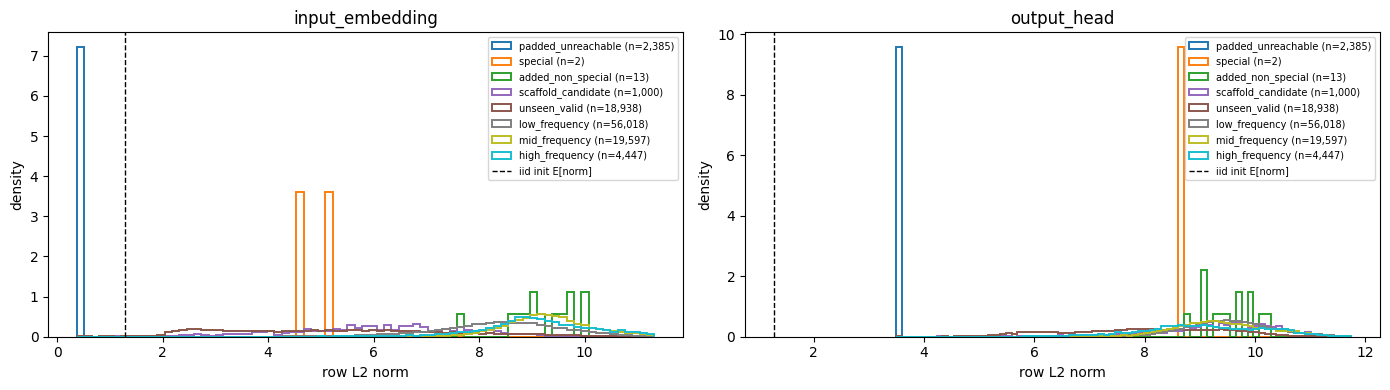

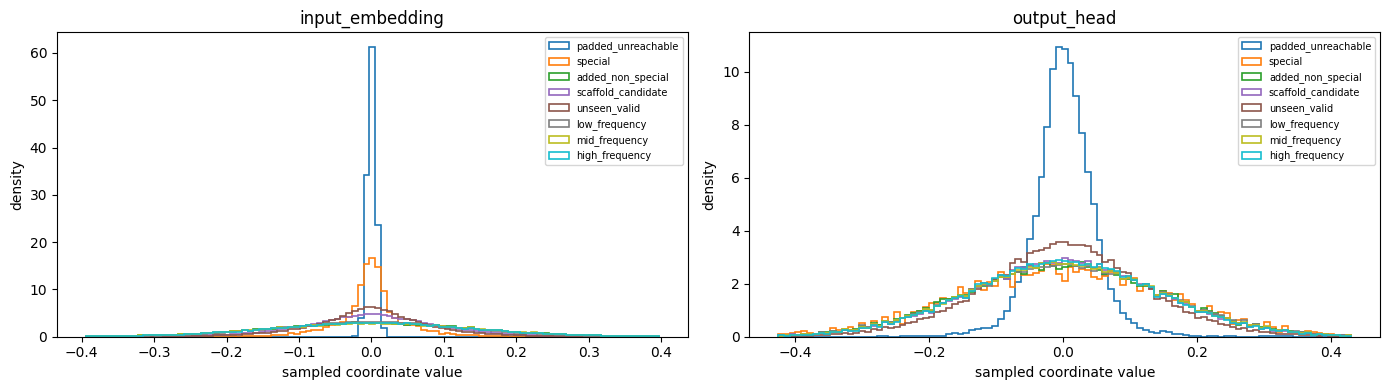

,matrix,analysis_group,sampled_coordinates,mean,std,skewness,excess_kurtosis
0,input_embedding,padded_unreachable,200000,0.000013,0.005987,0.001882,0.014823
1,input_embedding,special,8192,0.000446,0.075989,-4.882481,265.457031
2,input_embedding,added_non_special,53248,0.000264,0.144145,-0.016261,0.598831
3,input_embedding,scaffold_candidate,200000,-0.000145,0.098151,-0.009712,0.799535
4,input_embedding,unseen_valid,200000,-0.000253,0.088819,-0.002626,1.952548
5,input_embedding,low_frequency,200000,-0.000350,0.133138,-0.007705,0.241419
6,input_embedding,mid_frequency,200000,0.000332,0.145278,0.009895,0.100411
7,input_embedding,high_frequency,200000,-0.000222,0.145234,-0.020346,0.529596
8,output_head,padded_unreachable,200000,0.001864,0.054727,3.381810,102.562637
9,output_head,special,8192,-0.000739,0.163787,0.107421,2.196476


In [11]:
COLORS = dict(zip(GROUP_ORDER, plt.cm.tab10(np.linspace(0, 1, len(GROUP_ORDER)))))

fig, axes = plt.subplots(1, len(MATRICES_TO_ANALYZE), figsize=(7 * len(MATRICES_TO_ANALYZE), 4), squeeze=False)
for ax, matrix_name in zip(axes[0], MATRICES_TO_ANALYZE):
    part = row_metrics[row_metrics["matrix"] == matrix_name]
    lo, hi = part["row_norm"].quantile([0.002, 0.998])
    bins = np.linspace(lo, hi, 80)
    for group in GROUP_ORDER:
        values = part.loc[part["analysis_group"] == group, "row_norm"]
        if len(values):
            ax.hist(values, bins=bins, density=True, histtype="step", linewidth=1.4,
                    color=COLORS[group], label=f"{group} (n={len(values):,})")
    ax.axvline(EXPECTED_RANDOM_NORM, color="black", linestyle="--", linewidth=1,
               label="iid init E[norm]")
    ax.set(title=matrix_name, xlabel="row L2 norm", ylabel="density")
    ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(WEIGHT_OUTPUT_DIR / "row_norm_by_group.png", dpi=160)
plt.show()

coordinate_rows = []
fig, axes = plt.subplots(1, len(MATRICES_TO_ANALYZE), figsize=(7 * len(MATRICES_TO_ANALYZE), 4), squeeze=False)
for ax, matrix_name in zip(axes[0], MATRICES_TO_ANALYZE):
    vectors = weight_results[matrix_name]["vectors"]
    plotted = {}
    for group in GROUP_ORDER:
        mask = sample_index["analysis_group"].to_numpy() == group
        values = vectors[mask].reshape(-1)
        if not len(values):
            continue
        if len(values) > 200_000:
            values = rng.choice(values, 200_000, replace=False)
        plotted[group] = values
        centered = values - values.mean()
        std = values.std()
        coordinate_rows.append({
            "matrix": matrix_name,
            "analysis_group": group,
            "sampled_coordinates": len(values),
            "mean": values.mean(),
            "std": std,
            "skewness": np.mean(centered ** 3) / std ** 3,
            "excess_kurtosis": np.mean(centered ** 4) / std ** 4 - 3,
        })
    all_values = np.concatenate(list(plotted.values()))
    lo, hi = np.quantile(all_values, [0.002, 0.998])
    bins = np.linspace(lo, hi, 100)
    for group, values in plotted.items():
        ax.hist(values, bins=bins, density=True, histtype="step", linewidth=1.2,
                color=COLORS[group], label=group)
    ax.set(title=matrix_name, xlabel="sampled coordinate value", ylabel="density")
    ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(WEIGHT_OUTPUT_DIR / "coordinate_distribution_by_group.png", dpi=160)
plt.show()

coordinate_summary = pd.DataFrame(coordinate_rows)
coordinate_summary.to_csv(WEIGHT_OUTPUT_DIR / "coordinate_moments.csv", index=False)
coordinate_summary


### 2.4 权重和频率、BPE depth、脚手架属性的关系

这里使用 Spearman 相关，因为频率和 depth 都不是线性尺度。相关性仍然只是诊断：当前语料中的频率不等于预训练频率，depth 也同时受 token 字节长度和 merge 路径影响。


In [12]:
def spearman(x, y):
    valid = x.notna() & y.notna()
    return x[valid].rank(method="average").corr(y[valid].rank(method="average"))


correlation_rows = []
for matrix_name, part in row_metrics.groupby("matrix"):
    part = part[part["reachable"] & (part["kind"] == "merged")].copy()
    part["log_final_count"] = np.log1p(part["final_count"])
    part["log_internal_count"] = np.log1p(part["internal_count"])
    for weight_metric in ["row_norm", "row_std"]:
        for structure_metric in ["log_final_count", "log_internal_count", "depth", "final_ratio"]:
            correlation_rows.append({
                "matrix": matrix_name,
                "weight_metric": weight_metric,
                "structure_metric": structure_metric,
                "spearman": spearman(part[weight_metric], part[structure_metric]),
                "rows": len(part),
            })

structure_correlations = pd.DataFrame(correlation_rows)
structure_correlations.to_csv(WEIGHT_OUTPUT_DIR / "embedding_structure_correlations.csv", index=False)
structure_correlations.pivot(index=["matrix", "weight_metric"], columns="structure_metric", values="spearman")


structure_metric                  depth  final_ratio  log_final_count  \
matrix          weight_metric                                           
input_embedding row_norm      -0.268628    -0.023107         0.630317   
                row_std       -0.268629    -0.023111         0.630327   
output_head     row_norm      -0.374144    -0.202880         0.222339   
                row_std       -0.374171    -0.202891         0.222349   

structure_metric               log_internal_count  
matrix          weight_metric                      
input_embedding row_norm                 0.187900  
                row_std                  0.187906  
output_head     row_norm                 0.252919  
                row_std                  0.252932

In [13]:
# 给后续脚手架审查保留token级结果：z分数以同一矩阵中实际输出的普通频率组为参照。
focus_parts = []
ordinary_groups = {"low_frequency", "mid_frequency", "high_frequency"}
focus_groups = {"padded_unreachable", "scaffold_candidate", "unseen_valid"}
for matrix_name, part in row_metrics.groupby("matrix"):
    reference = part[part["analysis_group"].isin(ordinary_groups)]
    focus = part[part["analysis_group"].isin(focus_groups)].copy()
    for metric in ["row_norm", "row_std"]:
        focus[f"{metric}_z_vs_emitted"] = (
            focus[metric] - reference[metric].mean()
        ) / reference[metric].std()
    focus_parts.append(focus)

focus_diagnostics = pd.concat(focus_parts, ignore_index=True)
focus_diagnostics.to_csv(WEIGHT_OUTPUT_DIR / "padding_scaffold_unseen_diagnostics.csv", index=False)

scaffold_diagnostics = (
    focus_diagnostics[focus_diagnostics["analysis_group"] == "scaffold_candidate"]
    [[
        "matrix", "id", "token", "decoded", "depth", "merge_rank",
        "final_count", "internal_count", "final_ratio",
        "row_norm", "row_norm_z_vs_emitted", "row_std_z_vs_emitted",
    ]]
    .assign(abs_norm_z=lambda x: x["row_norm_z_vs_emitted"].abs())
    .sort_values(["matrix", "abs_norm_z"], ascending=[True, False])
)
scaffold_diagnostics.to_csv(WEIGHT_OUTPUT_DIR / "scaffold_weight_diagnostics.csv", index=False)
scaffold_diagnostics.groupby("matrix").head(20)


,matrix,id,token,decoded,depth,merge_rank,final_count,internal_count,final_ratio,row_norm,row_norm_z_vs_emitted,row_std_z_vs_emitted,abs_norm_z
4328,input_embedding,38991,rgell,rgell,3.0,38748.0,0,6,0.0,1.133002,-6.208494,-6.208546,6.208494
1550,input_embedding,20325,uetooth,uetooth,5.0,20082.0,0,2,0.0,1.366470,-6.015211,-6.015185,6.015211
1997,input_embedding,24161,artheta,artheta,4.0,23918.0,0,6,0.0,1.436020,-5.957632,-5.957571,5.957632
2540,input_embedding,27870,cknowledg,cknowledg,4.0,27627.0,0,20,0.0,1.524413,-5.884452,-5.884401,5.884452
3022,input_embedding,30878,trightarrow,trightarrow,4.0,30635.0,0,12,0.0,1.633962,-5.793759,-5.793660,5.793759
1609,input_embedding,20985,IMARY,IMARY,3.0,20742.0,0,8,0.0,1.827693,-5.633374,-5.633255,5.633374
971,input_embedding,15281,ctrine,ctrine,3.0,15038.0,0,67,0.0,2.027001,-5.468370,-5.468246,5.468370
6114,input_embedding,48378,ndefined,ndefined,3.0,48135.0,0,56,0.0,2.051005,-5.448497,-5.448375,5.448497
3814,input_embedding,36019,TEGER,TEGER,3.0,35776.0,0,16,0.0,2.133199,-5.380451,-5.380878,5.380451
1512,input_embedding,20065,precated,precated,4.0,19822.0,0,38,0.0,2.209365,-5.317395,-5.317228,5.317395


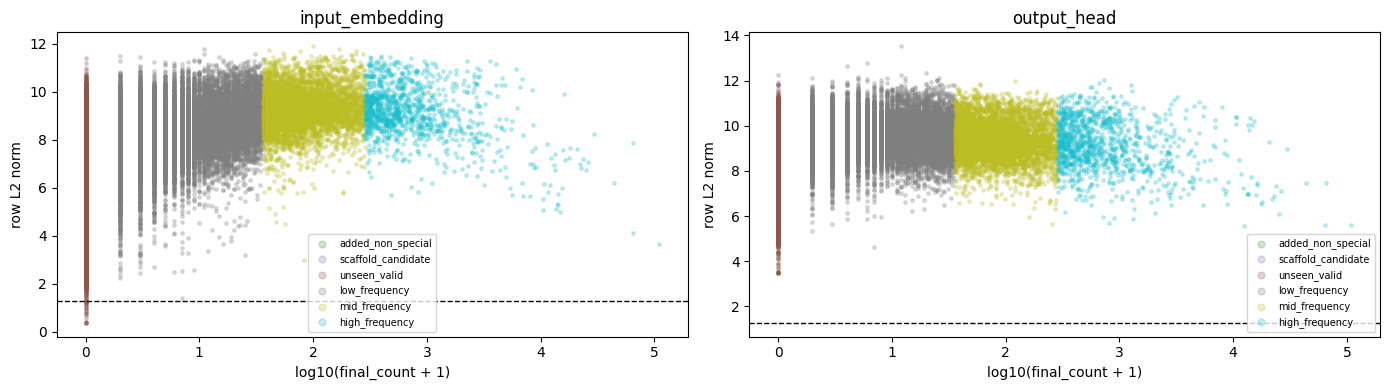

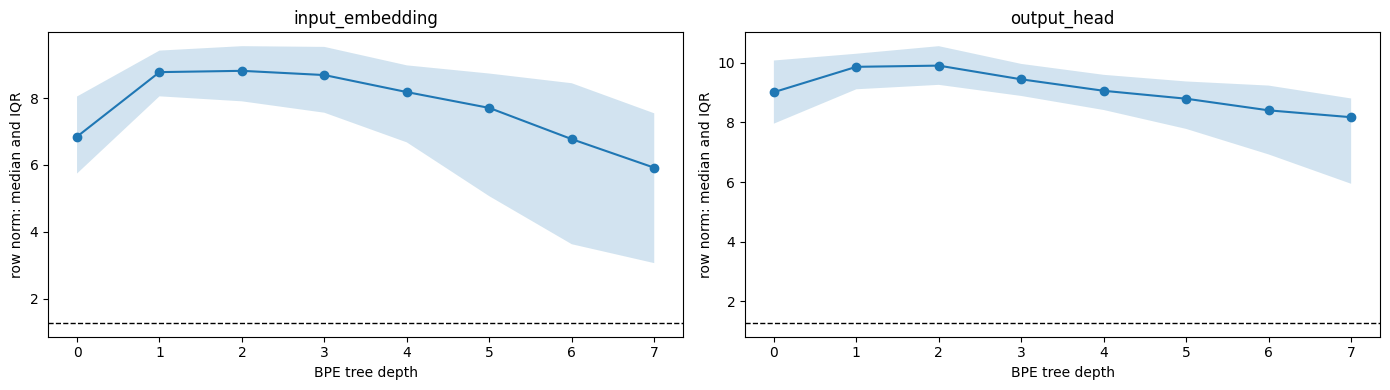

In [14]:
fig, axes = plt.subplots(1, len(MATRICES_TO_ANALYZE), figsize=(7 * len(MATRICES_TO_ANALYZE), 4), squeeze=False)
for ax, matrix_name in zip(axes[0], MATRICES_TO_ANALYZE):
    part = row_metrics[(row_metrics["matrix"] == matrix_name) & row_metrics["reachable"]]
    plot_part = part.sample(min(25_000, len(part)), random_state=RANDOM_SEED)
    for group in GROUP_ORDER:
        group_part = plot_part[plot_part["analysis_group"] == group]
        if len(group_part):
            ax.scatter(np.log10(group_part["final_count"] + 1), group_part["row_norm"],
                       s=6, alpha=0.25, color=COLORS[group], label=group)
    ax.axhline(EXPECTED_RANDOM_NORM, color="black", linestyle="--", linewidth=1)
    ax.set(title=matrix_name, xlabel="log10(final_count + 1)", ylabel="row L2 norm")
    ax.legend(fontsize=7, markerscale=2)
fig.tight_layout()
fig.savefig(WEIGHT_OUTPUT_DIR / "norm_vs_final_frequency.png", dpi=160)
plt.show()

depth_summary = (
    row_metrics[row_metrics["reachable"] & row_metrics["depth"].notna()]
    .groupby(["matrix", "depth"])["row_norm"]
    .agg(["size", "median", lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)])
    .reset_index()
)
depth_summary.columns = ["matrix", "depth", "rows", "median", "q25", "q75"]
depth_summary = depth_summary[depth_summary["rows"] >= 20]

fig, axes = plt.subplots(1, len(MATRICES_TO_ANALYZE), figsize=(7 * len(MATRICES_TO_ANALYZE), 4), squeeze=False)
for ax, matrix_name in zip(axes[0], MATRICES_TO_ANALYZE):
    part = depth_summary[depth_summary["matrix"] == matrix_name]
    ax.plot(part["depth"], part["median"], marker="o")
    ax.fill_between(part["depth"], part["q25"], part["q75"], alpha=0.2)
    ax.axhline(EXPECTED_RANDOM_NORM, color="black", linestyle="--", linewidth=1)
    ax.set(title=matrix_name, xlabel="BPE tree depth", ylabel="row norm: median and IQR")
fig.tight_layout()
fig.savefig(WEIGHT_OUTPUT_DIR / "norm_by_bpe_depth.png", dpi=160)
plt.show()


### 2.5 PCA、方向各向异性和近邻结构

这一步只在每组最多 256 行的固定分层样本上计算：

- `mean_pairwise_cosine`：整体是否集中到共同方向；越接近 0 越接近各向同性。
- `nearest_cosine`：在这份分层样本中的最近邻相似度；它依赖样本大小，适合在两张矩阵和各组之间作相对比较。
- PCA：观察 padding 行是否形成独立簇。`top16_variance_ratio` 只表示前 16 个主成分解释的方差，不是假装估计完整 effective rank。


,matrix,sample_rows,mean_pairwise_cosine,pc1_variance_ratio,top16_variance_ratio
0,input_embedding,1551,0.008836,0.011784,0.08377
1,output_head,1551,0.132966,0.031922,0.07262


,matrix,analysis_group,sample_rows,nearest_cosine_mean,nearest_cosine_median,centroid_cosine_mean
0,input_embedding,added_non_special,13,0.263744,0.282859,0.060594
1,input_embedding,high_frequency,256,0.208087,0.174865,0.044601
2,input_embedding,low_frequency,256,0.167107,0.149713,0.114577
3,input_embedding,mid_frequency,256,0.181826,0.156013,0.074793
4,input_embedding,padded_unreachable,256,0.052194,0.050976,0.007064
5,input_embedding,scaffold_candidate,256,0.190442,0.176597,0.167864
6,input_embedding,special,2,0.074142,0.074142,0.062717
7,input_embedding,unseen_valid,256,0.219116,0.197158,0.177281
8,output_head,added_non_special,13,0.354007,0.298702,0.195139
9,output_head,high_frequency,256,0.248687,0.188041,0.017510


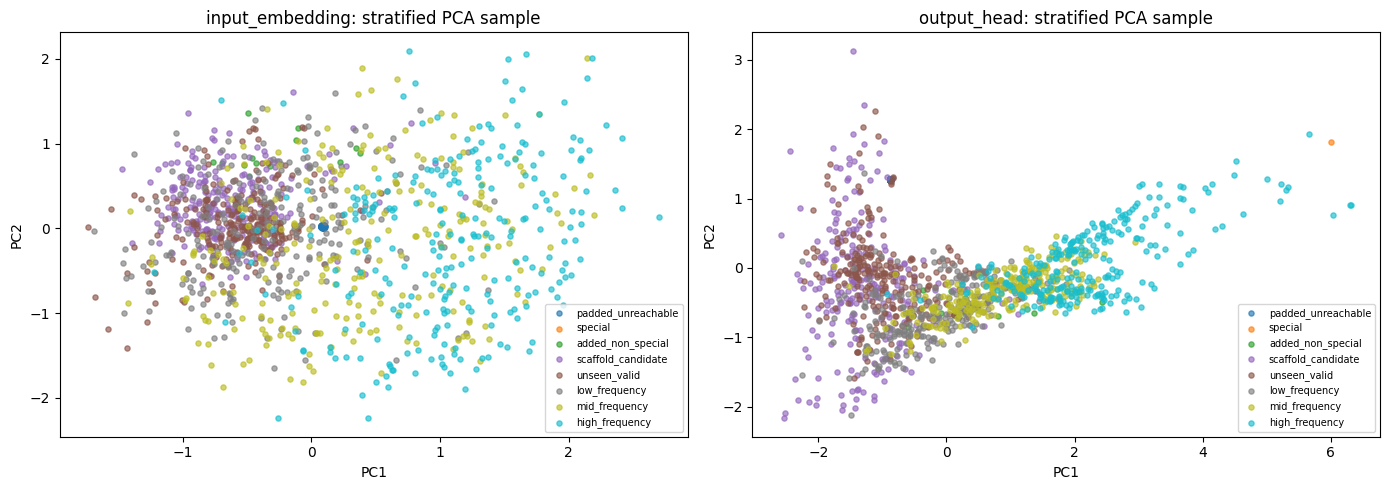

In [15]:
torch.manual_seed(RANDOM_SEED)
geometry_rows = []
geometry_global_rows = []
pca_results = {}

for matrix_name in MATRICES_TO_ANALYZE:
    x = torch.from_numpy(weight_results[matrix_name]["vectors"]).float()
    unit = F.normalize(x, dim=1)
    gram = unit @ unit.T
    gram.fill_diagonal_(-torch.inf)
    nearest = gram.max(dim=1).values

    centroid_direction = F.normalize(unit.mean(dim=0), dim=0)
    centroid_cosine = unit @ centroid_direction
    sum_direction = unit.sum(dim=0)
    n = len(unit)
    mean_pairwise_cosine = ((sum_direction @ sum_direction - n) / (n * (n - 1))).item()

    centered = x - x.mean(dim=0, keepdim=True)
    q = min(16, len(x) - 1, x.shape[1])
    _, singular_values, components = torch.pca_lowrank(centered, q=q, center=False)
    explained = singular_values.square() / centered.square().sum()
    pca_xy = (centered @ components[:, :2]).numpy()
    pca_results[matrix_name] = pca_xy

    sample_geometry = sample_index.copy()
    sample_geometry["nearest_cosine"] = nearest.numpy()
    sample_geometry["cosine_to_global_centroid"] = centroid_cosine.numpy()
    for group, part in sample_geometry.groupby("analysis_group"):
        geometry_rows.append({
            "matrix": matrix_name,
            "analysis_group": group,
            "sample_rows": len(part),
            "nearest_cosine_mean": part["nearest_cosine"].mean(),
            "nearest_cosine_median": part["nearest_cosine"].median(),
            "centroid_cosine_mean": part["cosine_to_global_centroid"].mean(),
        })
    geometry_global_rows.append({
        "matrix": matrix_name,
        "sample_rows": n,
        "mean_pairwise_cosine": mean_pairwise_cosine,
        "pc1_variance_ratio": explained[0].item(),
        "top16_variance_ratio": explained.sum().item(),
    })
    del x, unit, gram, centered

geometry_summary = pd.DataFrame(geometry_rows)
geometry_global = pd.DataFrame(geometry_global_rows)
geometry_summary.to_csv(WEIGHT_OUTPUT_DIR / "embedding_geometry_by_group.csv", index=False)
geometry_global.to_csv(WEIGHT_OUTPUT_DIR / "embedding_geometry_global.csv", index=False)
display(geometry_global)
display(geometry_summary)

fig, axes = plt.subplots(1, len(MATRICES_TO_ANALYZE), figsize=(7 * len(MATRICES_TO_ANALYZE), 5), squeeze=False)
for ax, matrix_name in zip(axes[0], MATRICES_TO_ANALYZE):
    xy = pca_results[matrix_name]
    for group in GROUP_ORDER:
        mask = sample_index["analysis_group"].to_numpy() == group
        if mask.any():
            ax.scatter(xy[mask, 0], xy[mask, 1], s=14, alpha=0.65,
                       color=COLORS[group], label=group)
    ax.set(title=f"{matrix_name}: stratified PCA sample", xlabel="PC1", ylabel="PC2")
    ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(WEIGHT_OUTPUT_DIR / "pca_by_group.png", dpi=160)
plt.show()


### 2.6 同一个 token 的 input/output 行是否对齐

只有同时分析两张表时才运行。模型没有 weight tying，因此余弦高低本身没有固定“正确答案”；这里关注 padding、scaffold、频率组之间是否出现系统差别。


In [16]:
if {"input_embedding", "output_head"}.issubset(weight_results):
    input_unit = F.normalize(torch.from_numpy(weight_results["input_embedding"]["vectors"]).float(), dim=1)
    output_unit = F.normalize(torch.from_numpy(weight_results["output_head"]["vectors"]).float(), dim=1)
    alignment = sample_index.copy()
    alignment["input_output_cosine"] = (input_unit * output_unit).sum(dim=1).numpy()
    alignment_summary = (
        alignment.groupby("analysis_group")["input_output_cosine"]
        .agg(["size", "mean", "median", "std"])
        .reindex(GROUP_ORDER)
    )
    alignment.to_csv(WEIGHT_OUTPUT_DIR / "input_output_alignment_sample.csv", index=False)
    display(alignment_summary)
else:
    print("只分析了一张矩阵，跳过 input/output 对齐。")


,size,mean,median,std
analysis_group,,,,
padded_unreachable,256,-0.000561,-0.000898,0.015304
special,2,0.017216,0.017216,0.021991
added_non_special,13,-0.003882,-0.008843,0.016378
scaffold_candidate,256,0.007825,0.008669,0.018688
unseen_valid,256,0.003584,0.002897,0.016380
low_frequency,256,0.009135,0.009402,0.018219
mid_frequency,256,0.002064,0.001465,0.022518
high_frequency,256,-0.018808,-0.015347,0.028850


### 2.7 可选：在真实 hidden state 上检查 `lm_head` 各组的概率质量

权重分布只能说明“看起来不同”，不能说明它在推理中真的造成问题。下面默认关闭；打开后会加载完整 7B 模型，并对中、英、法、代码提示的最后位置统计：每组总概率、组内平均单行概率、top-100 命中数，以及 embedding-only 行是否挤进候选。

这一步需要约 14 GB checkpoint 磁盘空间以及足够的 CPU/GPU RAM；如果前面已分析两张权重，文件通常已经在 Hugging Face cache 中。


In [17]:
RUN_LOGIT_PROBE = False
PROBE_TEXTS = {
    "en": "The most important consequence of this result is",
    "fr": "La conséquence la plus importante de ce résultat est",
    "zh": "这个结果最重要的意义是",
    "code": "def merge_tokens(left, right):\n    return",
}

if RUN_LOGIT_PROBE:
    from transformers import AutoModelForCausalLM, AutoTokenizer

    probe_tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
    probe_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=dtype,
        device_map="auto",
        low_cpu_mem_usage=True,
    ).eval()
    input_device = probe_model.get_input_embeddings().weight.device
    group_ids = {
        group: torch.tensor(
            token_table.loc[token_table["analysis_group"] == group, "id"].to_numpy(),
            device=input_device,
            dtype=torch.long,
        )
        for group in GROUP_ORDER
    }
    group_id_sets = {
        group: set(token_table.loc[token_table["analysis_group"] == group, "id"].astype(int))
        for group in GROUP_ORDER
    }

    logit_rows = []
    with torch.inference_mode():
        for prompt_name, text in PROBE_TEXTS.items():
            inputs = probe_tokenizer(text, return_tensors="pt").to(input_device)
            logits = probe_model(**inputs).logits[0, -1].float()
            log_z = torch.logsumexp(logits, dim=0)
            top100 = logits.topk(100).indices.tolist()
            for group, ids in group_ids.items():
                if not len(ids):
                    continue
                mass = torch.exp(torch.logsumexp(logits[ids], dim=0) - log_z).item()
                logit_rows.append({
                    "prompt": prompt_name,
                    "analysis_group": group,
                    "rows": len(ids),
                    "probability_mass": mass,
                    "mean_probability_per_row": mass / len(ids),
                    "top100_rows": sum(token_id in group_id_sets[group] for token_id in top100),
                    "max_logit": logits[ids].max().item(),
                })

    logit_probe = pd.DataFrame(logit_rows)
    logit_probe.to_csv(WEIGHT_OUTPUT_DIR / "real_logit_group_probe.csv", index=False)
    display(logit_probe)
else:
    print("RUN_LOGIT_PROBE=False：只完成静态权重诊断。")


RUN_LOGIT_PROBE=False：只完成静态权重诊断。


### 解释边界

1. 最终 checkpoint 没有初始化快照，所以“接近初始化分布”只能是证据，不能证明从未更新。
2. input padding 行和 output padding 行的训练机制不同，不能把两张表混成一条曲线。
3. 本 notebook 的高/中/低频来自小规模外部评估语料；要研究真实训练频率，需要训练语料统计或训练日志。
4. norm、PCA、近邻和 logits 是互补证据。任何单一指标都不能直接把 token 判为“应该删除”。
5. 删除 BPE token 还会改变后续 merge 的可达路径；权重异常只适合筛选候选，不能单独授权改词表。


### 2.8 打包并直接下载结果

运行下面单元后，Colab 会下载 `deepseek_7b_bpe_embedding_analysis.zip`。压缩包只包含统计结果、图和实验配置，不包含模型权重。


In [18]:
from zipfile import ZIP_DEFLATED, ZipFile

from google.colab import files

BUNDLE_PATH = Path("deepseek_7b_bpe_embedding_analysis.zip")

# 把没有单独落盘、但解释结果时需要的表一并保存。
corpus_stats_df.to_csv(WEIGHT_OUTPUT_DIR / "corpus_stats.csv", index=False)
group_overview.reset_index().to_csv(WEIGHT_OUTPUT_DIR / "token_group_overview.csv", index=False)

analysis_config = {
    "model_id": MODEL_ID,
    "model_vocab_size": MODEL_VOCAB_SIZE,
    "tokenizer_reachable_ids": len(vocab),
    "hidden_size": HIDDEN_SIZE,
    "initializer_range": INIT_STD,
    "target_bytes_per_corpus": TARGET_BYTES_PER_CORPUS,
    "corpora": CORPORA,
    "matrices_analyzed": list(MATRICES_TO_ANALYZE),
    "frequency_mass_cuts": list(FREQUENCY_MASS_CUTS),
    "scaffold_top_n": SCAFFOLD_TOP_N,
    "sample_rows_per_group": SAMPLE_ROWS_PER_GROUP,
    "random_seed": RANDOM_SEED,
    "ran_logit_probe": RUN_LOGIT_PROBE,
}
(WEIGHT_OUTPUT_DIR / "analysis_config.json").write_text(
    json.dumps(analysis_config, ensure_ascii=False, indent=2), encoding="utf-8"
)

with ZipFile(BUNDLE_PATH, "w", compression=ZIP_DEFLATED, compresslevel=6) as archive:
    archive.write(OUTPUT_PATH, arcname=OUTPUT_PATH.name)
    for path in sorted(WEIGHT_OUTPUT_DIR.rglob("*")):
        if path.is_file():
            archive.write(path, arcname=path.as_posix())

print(f"bundle: {BUNDLE_PATH.resolve()}")
print(f"size: {BUNDLE_PATH.stat().st_size / 1e6:.1f} MB")
files.download(str(BUNDLE_PATH))


bundle: /content/deepseek_7b_bpe_embedding_analysis.zip
size: 15.4 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>